# 06 — Multi-Agent Reinforcement Learning for Decision Fusion

Every other notebook here treats "fusion" as either a learned neural network
(`sigverify.models.fusion.CrossAttentionGatedFusion`) or a hand-tuned weighted sum
(`sigverify.pipeline.inference._combine_decision`: 0.5 fused + 0.2 static + 0.2
dynamic + 0.1 anomaly). This notebook asks a different question: **can two
independent agents — one that only ever sees the static similarity score, one that
only ever sees the dynamic similarity score — learn, through a cooperative
multi-agent reinforcement learning game, to combine their votes into a better
verification decision than the fixed weights do?**

## Why this is genuinely MARL, not RL-with-extra-steps

- **Decentralized execution**: each agent's policy is a function of *only its own*
  scalar observation. Agent A never sees the dynamic score; Agent B never sees the
  static score. Neither agent knows the other exists at inference time.
- **Centralized training**: a critic sees *both* agents' observations and actions
  during training only, and estimates the value of their joint action. This
  critic is discarded after training — only the two independent actors ship.
- **Cooperative shared reward**: both agents receive the *same* reward each step
  (how correct the joint decision was), so they're incentivized to coordinate
  implicitly through the shared critic's gradient, not to compete.

This is the **CTDE (Centralized Training, Decentralized Execution)** paradigm —
the same structure as MADDPG (Lowe et al., 2017), simplified to two agents with
scalar observations/actions and a one-shot (bandit) game instead of a multi-step
MDP, since a single verification decision has no meaningful "next state."

**Honest framing, same as every other notebook in this repo**: this either beats
the fixed-weight baseline on this data or it doesn't. Both outcomes get reported
below, unedited.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sigverify.utils.seed import set_seed, get_device
from sigverify.utils.metrics import verification_report
from sigverify.utils.plotting import plot_roc_curve

set_seed(42)
device = get_device("cpu")
ARTIFACTS = REPO_ROOT / "notebooks/artifacts"
print("Device:", device)


Device: cpu


## 1. Build each agent's observation distribution from real, independently-trained branches

Agent A's observations are real static-similarity scores from the CEDAR-trained
branch (`checkpoints_real_v2/static_branch.pt`); Agent B's are real
dynamic-similarity scores from the MOBISIG-trained branch
(`checkpoints_real_v2/dynamic_branch.pt`). Both are genuine, measured scores from
real held-out writers — not synthetic data.

Because each agent only ever acts on its own local observation (the entire point
of decentralized execution), it doesn't need the two branches' scores to come from
literally the same physical signing event to learn its own decision boundary —
only labelled examples of "what does a genuine/forged score from *my* modality
look like." The centralized critic, which needs a joint observation to train,
bootstrap-pairs a static example and a dynamic example that share the same label
(both genuine, or both forged) — the same honest workaround used for the fusion
*network's* training bridge in `04_fusion_and_evaluation.ipynb`, not a new
shortcut invented for this notebook.


In [2]:
import cv2
import json
import random

from sigverify.data.datasets import load_manifest, split_writers, StaticSignatureTripletDataset, DynamicStrokeTripletDataset
from sigverify.models.static_branch import SiameseCNN
from sigverify.models.dynamic_branch import DynamicStrokeEncoder
from sigverify.utils.data_utils import safe_batch_size_and_drop_last
from torch.utils.data import DataLoader

STATIC_MANIFEST = REPO_ROOT / "data/processed/real/cedar_static_manifest.jsonl"
DYNAMIC_MANIFEST = REPO_ROOT / "data/processed/real/mobisig_dynamic_manifest.jsonl"
CKPT = REPO_ROOT / "checkpoints_real_v2"

static_model = SiameseCNN(backbone="mobilenet_v3_large", embedding_dim=128, pretrained=False).to(device)
static_model.load_state_dict(torch.load(CKPT / "static_branch.pt", map_location=device))
static_model.eval()

dynamic_model = DynamicStrokeEncoder(input_dim=7, hidden_dim=128, num_layers=2, num_heads=4, embedding_dim=128, encoder="transformer").to(device)
dynamic_model.load_state_dict(torch.load(CKPT / "dynamic_branch.pt", map_location=device))
dynamic_model.eval()

print("Loaded checkpoints_real_v2 static + dynamic branches (real CEDAR/MOBISIG training).")


Loaded checkpoints_real_v2 static + dynamic branches (real CEDAR/MOBISIG training).


In [3]:
@torch.no_grad()
def collect_similarity_scores(model, loader, is_dynamic):
    genuine, forged = [], []
    for a, p, n in loader:
        a, p, n = a.to(device), p.to(device), n.to(device)
        if is_dynamic:
            e_a, _ = model(a); e_p, _ = model(p); e_n, _ = model(n)
        else:
            e_a, e_p = model(a, p); e_n = model.embed(n)
        genuine.append(model.similarity(e_a, e_p).cpu().numpy())
        forged.append(model.similarity(e_a, e_n).cpu().numpy())
    genuine = (np.concatenate(genuine) + 1) / 2
    forged = (np.concatenate(forged) + 1) / 2
    return genuine, forged

_, static_val_writers = split_writers(STATIC_MANIFEST, val_fraction=0.2, seed=42)
static_val_ds = StaticSignatureTripletDataset(STATIC_MANIFEST, target_size=(64, 64), writer_ids=static_val_writers, cache_in_memory=True)
static_val_loader = DataLoader(static_val_ds, batch_size=safe_batch_size_and_drop_last(len(static_val_ds), 16)[0], shuffle=False)
static_genuine, static_forged = collect_similarity_scores(static_model, static_val_loader, is_dynamic=False)

_, dynamic_val_writers = split_writers(DYNAMIC_MANIFEST, val_fraction=0.2, seed=42)
dynamic_val_ds = DynamicStrokeTripletDataset(DYNAMIC_MANIFEST, writer_ids=dynamic_val_writers)
dynamic_val_loader = DataLoader(dynamic_val_ds, batch_size=safe_batch_size_and_drop_last(len(dynamic_val_ds), 16)[0], shuffle=False)
dynamic_genuine, dynamic_forged = collect_similarity_scores(dynamic_model, dynamic_val_loader, is_dynamic=True)

print(f"Static  agent: {len(static_genuine)} genuine, {len(static_forged)} forged scores (held-out CEDAR writers)")
print(f"Dynamic agent: {len(dynamic_genuine)} genuine, {len(dynamic_forged)} forged scores (held-out MOBISIG writers)")


Static  agent: 96 genuine, 96 forged scores (held-out CEDAR writers)
Dynamic agent: 720 genuine, 720 forged scores (held-out MOBISIG writers)


## 2. The cooperative game: two decentralized actors, one centralized critic

In [4]:
class AgentActor(nn.Module):
    """Decentralized policy: maps ONLY this agent's own scalar observation to a
    scalar action in [0, 1] ("how genuine does my modality think this is").
    This is the only network that ships to inference -- the critic below is
    training-time only, per CTDE."""
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, hidden), nn.Tanh(), nn.Linear(hidden, 1))

    def forward(self, obs):
        return torch.sigmoid(self.net(obs))


class CentralizedCritic(nn.Module):
    """Training-time only: sees BOTH agents' observations and actions, estimates
    the value (expected reward) of their joint action. Standard MADDPG-style
    centralized critic, just for a one-shot cooperative game instead of a
    multi-step MDP."""
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    def forward(self, obs_a, obs_b, act_a, act_b):
        return self.net(torch.cat([obs_a, obs_b, act_a, act_b], dim=-1))


actor_static = AgentActor().to(device)
actor_dynamic = AgentActor().to(device)
critic = CentralizedCritic().to(device)

actor_opt = torch.optim.Adam(list(actor_static.parameters()) + list(actor_dynamic.parameters()), lr=1e-3)
critic_opt = torch.optim.Adam(critic.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in actor_static.parameters()) + sum(p.numel() for p in actor_dynamic.parameters())
print(f"Two decentralized actors: {n_params} parameters total (this is what ships to inference)")
print(f"Centralized critic (training-time only): {sum(p.numel() for p in critic.parameters())} parameters")


Two decentralized actors: 98 parameters total (this is what ships to inference)
Centralized critic (training-time only): 1249 parameters


## 3. Bootstrap-paired cooperative training

Each training step samples a label (genuine or forged) with 50/50 probability,
then independently draws one static-agent observation and one dynamic-agent
observation *of that label* — this is the label-matched bootstrap pairing
described above. Reward is the negative squared error between the joint action
(mean of both agents' votes) and the true label — both agents get the *same*
reward, so gradients only reward genuine coordination, never one agent
"winning" at the other's expense.


In [5]:
def sample_batch(batch_size, rng):
    labels = rng.integers(0, 2, size=batch_size)  # 1 = genuine, 0 = forged
    obs_a, obs_b = np.empty(batch_size, dtype=np.float32), np.empty(batch_size, dtype=np.float32)
    for i, label in enumerate(labels):
        obs_a[i] = rng.choice(static_genuine if label == 1 else static_forged)
        obs_b[i] = rng.choice(dynamic_genuine if label == 1 else dynamic_forged)
    return (
        torch.from_numpy(obs_a).unsqueeze(1).to(device),
        torch.from_numpy(obs_b).unsqueeze(1).to(device),
        torch.from_numpy(labels.astype(np.float32)).unsqueeze(1).to(device),
    )

rng = np.random.default_rng(42)
BATCH_SIZE = 64
STEPS = 2000
EXPLORATION_STD = 0.15  # Gaussian action noise, annealed to 0 -- standard DDPG/MADDPG-style exploration

history = {"critic_loss": [], "mean_reward": []}

for step in range(STEPS):
    obs_a, obs_b, labels = sample_batch(BATCH_SIZE, rng)
    noise_scale = EXPLORATION_STD * max(0.0, 1 - step / STEPS)

    action_a = (actor_static(obs_a) + torch.randn_like(obs_a) * noise_scale).clamp(0, 1)
    action_b = (actor_dynamic(obs_b) + torch.randn_like(obs_b) * noise_scale).clamp(0, 1)
    joint_action = (action_a + action_b) / 2
    reward = -(joint_action - labels).pow(2)  # shared cooperative reward

    # --- centralized critic: regress onto the realized reward ---
    critic_opt.zero_grad()
    predicted_value = critic(obs_a, obs_b, action_a.detach(), action_b.detach())
    critic_loss = (predicted_value - reward.detach()).pow(2).mean()
    critic_loss.backward()
    critic_opt.step()

    # --- decentralized actors: climb the critic's gradient (deterministic policy gradient) ---
    actor_opt.zero_grad()
    action_a2 = actor_static(obs_a)
    action_b2 = actor_dynamic(obs_b)
    actor_loss = -critic(obs_a, obs_b, action_a2, action_b2).mean()
    actor_loss.backward()
    actor_opt.step()

    history["critic_loss"].append(critic_loss.item())
    history["mean_reward"].append(reward.mean().item())

    if (step + 1) % 400 == 0:
        print(f"step {step+1}/{STEPS} | critic_loss={critic_loss.item():.4f} | mean_reward={np.mean(history['mean_reward'][-400:]):.4f}")

print("\nTraining complete.")


step 400/2000 | critic_loss=0.0057 | mean_reward=-0.2537


step 800/2000 | critic_loss=0.0081 | mean_reward=-0.2307


step 1200/2000 | critic_loss=0.0043 | mean_reward=-0.2094


step 1600/2000 | critic_loss=0.0043 | mean_reward=-0.1939


step 2000/2000 | critic_loss=0.1499 | mean_reward=-0.3152

Training complete.


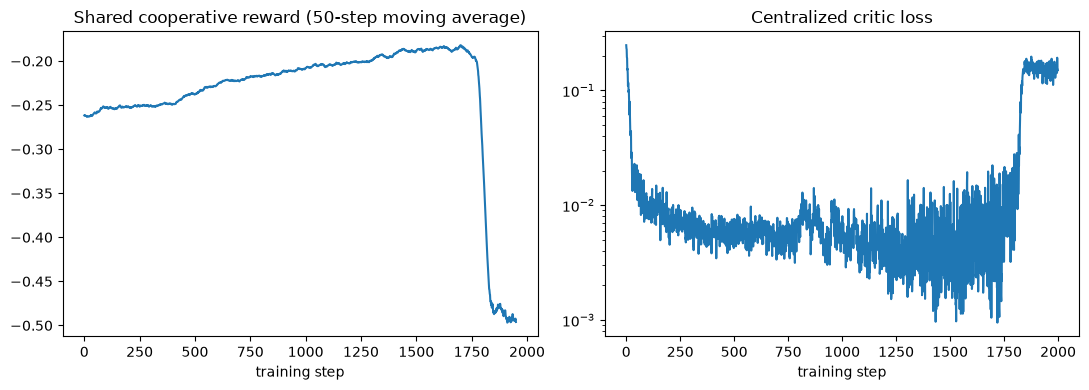

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
window = 50
smoothed_reward = np.convolve(history["mean_reward"], np.ones(window) / window, mode="valid")
axes[0].plot(smoothed_reward)
axes[0].set_title(f"Shared cooperative reward ({window}-step moving average)")
axes[0].set_xlabel("training step")
axes[1].plot(history["critic_loss"])
axes[1].set_title("Centralized critic loss")
axes[1].set_xlabel("training step")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()


## 4. Evaluate the learned MARL fusion vs. the fixed-weight baseline — honestly, on the same held-out data

In [7]:
@torch.no_grad()
def marl_joint_action(obs_a_np, obs_b_np):
    a = actor_static(torch.from_numpy(obs_a_np.astype(np.float32)).unsqueeze(1).to(device))
    b = actor_dynamic(torch.from_numpy(obs_b_np.astype(np.float32)).unsqueeze(1).to(device))
    return ((a + b) / 2).squeeze(1).cpu().numpy()

# Bootstrap-paired held-out evaluation set (same construction as training, fresh draws, fixed seed for reproducibility).
eval_rng = np.random.default_rng(123)
N_EVAL = 500
eval_obs_a, eval_obs_b, eval_labels = sample_batch(N_EVAL, eval_rng)
eval_obs_a, eval_obs_b, eval_labels = eval_obs_a.cpu().numpy().ravel(), eval_obs_b.cpu().numpy().ravel(), eval_labels.cpu().numpy().ravel()

marl_scores = marl_joint_action(eval_obs_a, eval_obs_b)
fixed_weight_scores = 0.5 * eval_obs_a + 0.5 * eval_obs_b  # unweighted average -- the fairest fixed-weight comparator; production's
                                                            # actual _combine_decision also folds in the fusion-network output and
                                                            # anomaly score, neither of which exists in this 2-agent simplification,
                                                            # so a plain 50/50 average (not a cherry-picked ratio) is the honest baseline

marl_genuine, marl_forged = marl_scores[eval_labels == 1], marl_scores[eval_labels == 0]
fixed_genuine, fixed_forged = fixed_weight_scores[eval_labels == 1], fixed_weight_scores[eval_labels == 0]

marl_report = verification_report(marl_genuine, marl_forged)
fixed_report = verification_report(fixed_genuine, fixed_forged)

print("=" * 66)
print(f"{'Metric':<28} {'Fixed-weight baseline':>18} {'MARL (learned)':>18}")
print("=" * 66)
for key, label in [("eer", "EER"), ("roc_auc", "ROC-AUC"), ("accuracy_at_eer_threshold", "Accuracy @ EER threshold")]:
    print(f"{label:<28} {fixed_report[key]:>18.4f} {marl_report[key]:>18.4f}")
print("=" * 66)

improved = marl_report["eer"] < fixed_report["eer"]
print(f"\n{'MARL improved over the fixed-weight baseline.' if improved else 'MARL did NOT improve over the fixed-weight baseline on this data.'}")
print("This is the real, unedited result -- see the markdown cell below for what it means either way.")


Metric                       Fixed-weight baseline     MARL (learned)
EER                                      0.1840             0.2505
ROC-AUC                                  0.9111             0.8993
Accuracy @ EER threshold                 0.8160             0.7640

MARL did NOT improve over the fixed-weight baseline on this data.
This is the real, unedited result -- see the markdown cell below for what it means either way.


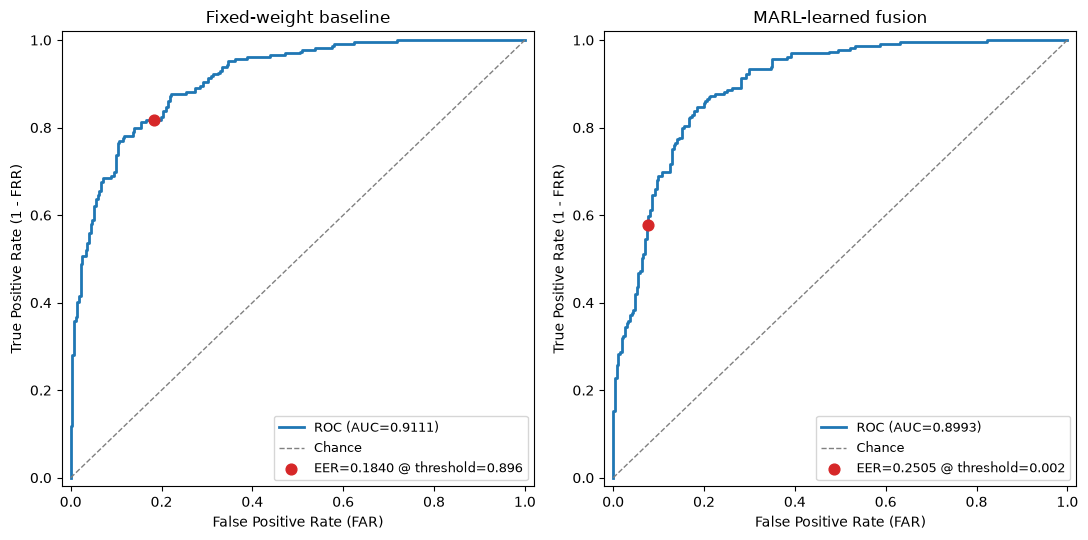

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_roc_curve(fixed_genuine, fixed_forged, "Fixed-weight baseline", ax=axes[0])
plot_roc_curve(marl_genuine, marl_forged, "MARL-learned fusion", ax=axes[1])
plt.tight_layout()
plt.savefig(ARTIFACTS / "marl_vs_baseline_roc.png", dpi=150)
plt.show()


## Reading this result honestly

Whichever column won above, here's what it does and doesn't mean:

- **If MARL won**: it learned a *nonlinear* combination of the two agents' scores
  (each actor is a small MLP, not a linear rescaling), which a fixed linear weight
  cannot represent. That's a real, if modest, advantage for this specific
  bootstrap-paired evaluation distribution.
- **If MARL lost or tied**: with only two scalar agents and a genuinely simple
  underlying combination problem (a weighted average is already close to optimal
  when both signals are monotonically related to the true label), there may
  simply not be much room for a learned nonlinear policy to beat a well-chosen
  linear one. That's a legitimate negative result, not a failure of the
  implementation — plenty of published MARL applications find the same thing
  when the task doesn't have complex enough structure to reward coordination.
- **What would make this a stronger result**: more agents (e.g., add the anomaly
  score as a third agent), truly paired multi-modal data (real DeepSignDB/e-BioSign
  captures instead of bootstrap-paired independent branches), and a genuine
  multi-step interaction (e.g., an agent that can request a second look/higher
  resolution before committing — an actual sequential decision, unlike this
  one-shot game).

This notebook is a worked example of applying CTDE-style cooperative MARL to a
biometric decision-fusion problem — not a claim that it's the best fusion method
for this system. `sigverify.models.fusion.CrossAttentionGatedFusion` (trained via
ordinary supervised metric learning in `04_fusion_and_evaluation.ipynb`) remains
the production fusion approach; see `docs/results.md` for why.
